# Visualization of regridded GPM DPR data for SCREAM evaluation


Created by Julia Kukulies (j.kukulies@reading.ac.uk) 

Last updated: May 2026

In [2]:
import h5py
import numpy as np
import xarray as xr
from pathlib import Path
import os
import sys 
import scipy
from datetime import datetime, timedelta
import pandas as pd

# pansat library
import pansat
from pansat.environment import get_index
from pansat import TimeRange
from pansat.geometry import LonLatRect 
from pansat.granule import merge_granules
from pansat.catalog import Index
from pansat.products.satellite.gpm import l2a_gpm_dpr

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs

cmap = get_cmap("magma")
cmap.set_bad("lightgrey")

## Granule source files 

The source file of the granule contains the original swath data with dimensions **(scans, rays, bins)**:

In [3]:
path = Path('/glade/derecho/scratch/kukulies/gpm_dpr/202002/')
gridfile_src= path / '2A.GPM.DPR.V9-20211125.20200228-S153908-E171142.034100.V07A_2020-02-28T16:30:00_src-grid.nc'
granule_ds = xr.open_dataset(gridfile_src)

In [4]:
granule_ds

<xarray.Dataset> Size: 835MB
Dimensions:              (scans: 7936, rays: 49, bins: 176)
Coordinates:
  * scans                (scans) int64 63kB 0 1 2 3 4 ... 7932 7933 7934 7935
  * rays                 (rays) int64 392B 0 1 2 3 4 5 6 ... 43 44 45 46 47 48
  * bins                 (bins) int64 1kB 0 1 2 3 4 5 ... 171 172 173 174 175
    frequencies          int64 8B ...
    latitude             (scans, rays) float32 2MB ...
    longitude            (scans, rays) float32 2MB ...
    scan_time            (scans) datetime64[ns] 63kB ...
Data variables:
    precip_rate          (scans, rays, bins) float32 274MB ...
    surface_precip       (scans, rays) float32 2MB ...
    reflectivity         (scans, rays, bins) float32 274MB ...
    precip_type          (scans, rays) float64 3MB ...
    precip_type_quality  (scans, rays) float64 3MB ...
    height               (scans, rays, bins) float32 274MB ...
    path_attenuation     (scans, rays) float32 2MB ...
    freezing_level       (scans, rays) float32 2MB ...

##  Visualization of granule source file 

#### Surface precipitation

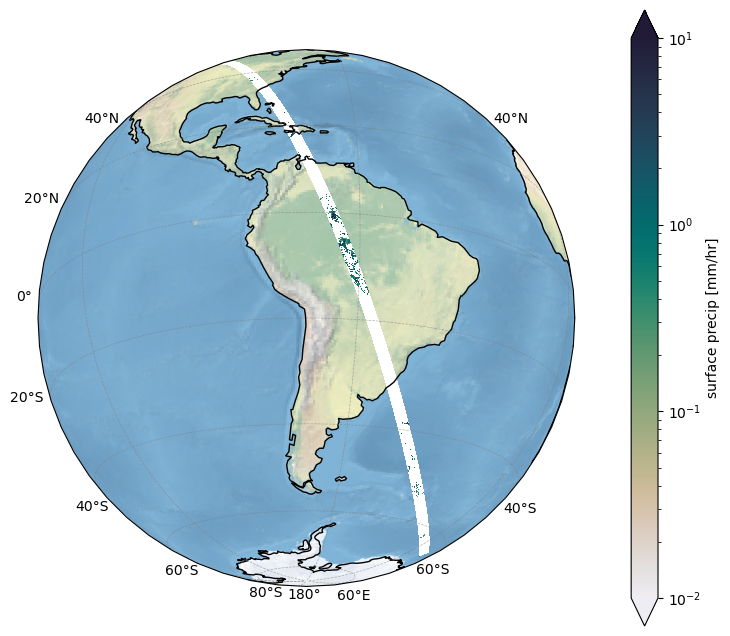

In [6]:
import cmocean 
cmap = cmocean.cm.rain
cmap.set_bad("white")

gs = GridSpec(1, 2, width_ratios=[1.0, 0.05])
fig = plt.figure(figsize=(8, 8))

norm = LogNorm(1e-2,1e1)
lats, lons = granule_ds.latitude.values, granule_ds.longitude.values

proj = ccrs.NearsidePerspective(central_latitude=-20,
                                central_longitude=-70)
ax = plt.subplot(gs[0], projection=proj)
ax.stock_img()
ax.coastlines()
sm = ax.pcolormesh(lons, lats, granule_ds.surface_precip.values, cmap=cmap, norm  = norm,  transform=ccrs.PlateCarree()) 

### add lats and lons for better orientation
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.6,
    linestyle='--'
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

ax = plt.subplot(gs[1])
plt.colorbar(sm, extend = 'both', cax=ax, fraction=0.35, pad=0.2, label="surface precip [mm/hr]")
plt.show()

#### Zoom in over South America 

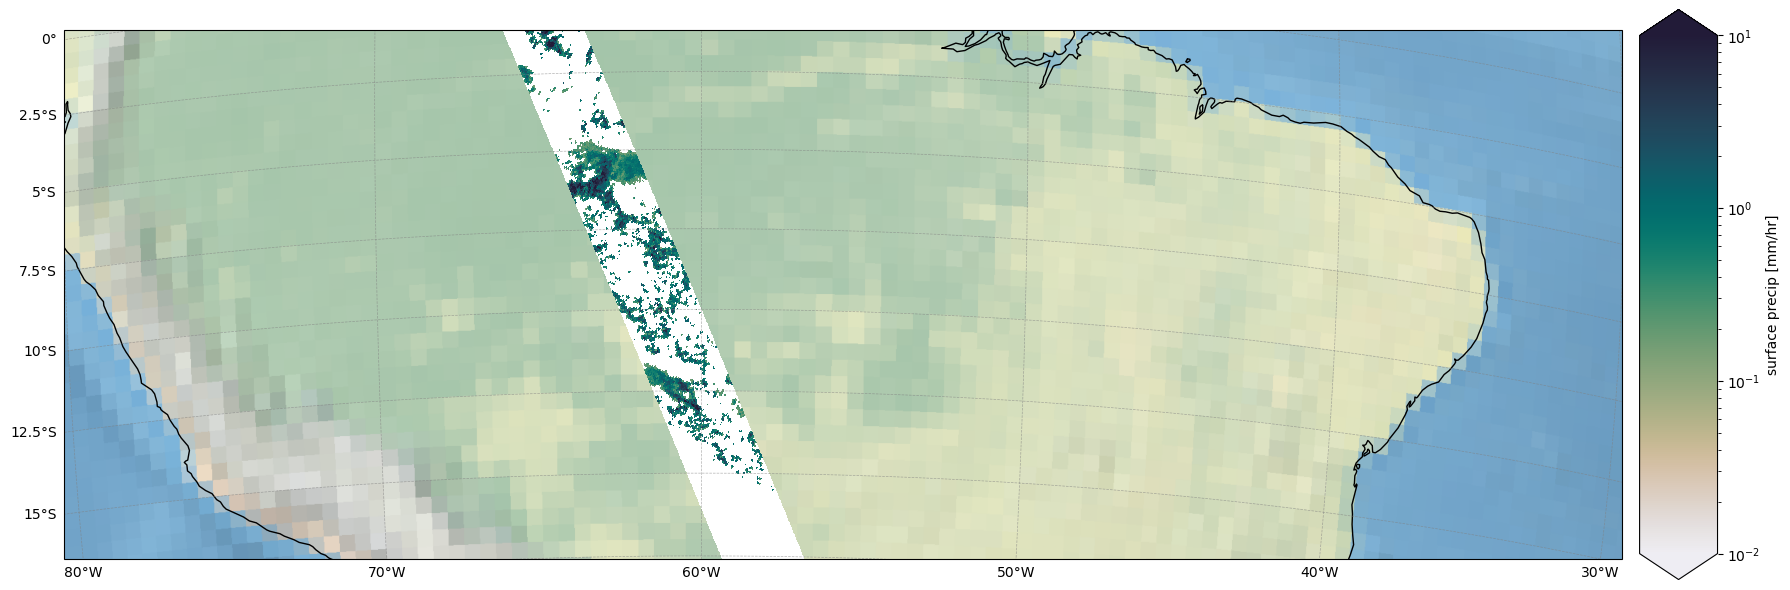

In [9]:
gs = GridSpec(1, 2, width_ratios=[1.0, 0.05])

fig = plt.figure(figsize=(18, 6))

proj = ccrs.NearsidePerspective(
    central_latitude=-20,
    central_longitude=-60,
)

ax = plt.subplot(gs[0], projection=proj)

# Zoom to South America
ax.set_extent(
    [-80, -30, -15, 0],   # [west, east, south, north]
    crs=ccrs.PlateCarree()
)

ax.stock_img()
ax.coastlines(resolution='50m')

sm = ax.pcolormesh(
    lons,
    lats,
    granule_ds.surface_precip.values,
    cmap=cmap,
    norm=norm,
    transform=ccrs.PlateCarree()
)

# Gridlines
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.6,
    linestyle='--'
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# Colorbar
cax = plt.subplot(gs[1])

plt.colorbar(
    sm,
    extend='both',
    cax=cax,
    fraction=0.35,
    pad=0.2,
    label="surface precip [mm/hr]") 

plt.tight_layout()
plt.show()

###  Composite reflectivity

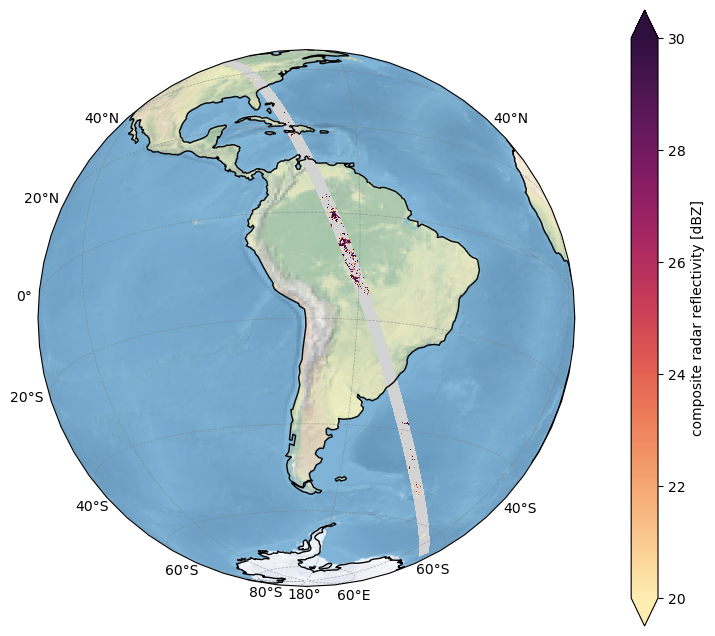

In [28]:
gs = GridSpec(1, 2, width_ratios=[1.0, 0.05])
fig = plt.figure(figsize=(8, 8))
cmap = cmocean.cm.matter
cmap.set_bad("lightgrey")

proj = ccrs.NearsidePerspective(central_latitude=-20,
                                central_longitude=-70)
ax = plt.subplot(gs[0], projection=proj)
ax.stock_img()
ax.coastlines()
sm = ax.pcolormesh(lons, lats, granule_ds.reflectivity.max('bins'), cmap=cmap, vmin = 20, vmax = 30, transform=ccrs.PlateCarree()) 

### add lats and lons for better orientation
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.6,
    linestyle='--')

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

ax = plt.subplot(gs[1])
plt.colorbar(sm, extend = 'both', cax=ax, fraction=0.35, pad=0.2, label="composite radar reflectivity [dBZ]")
plt.show()

#### Zoom in over South America 

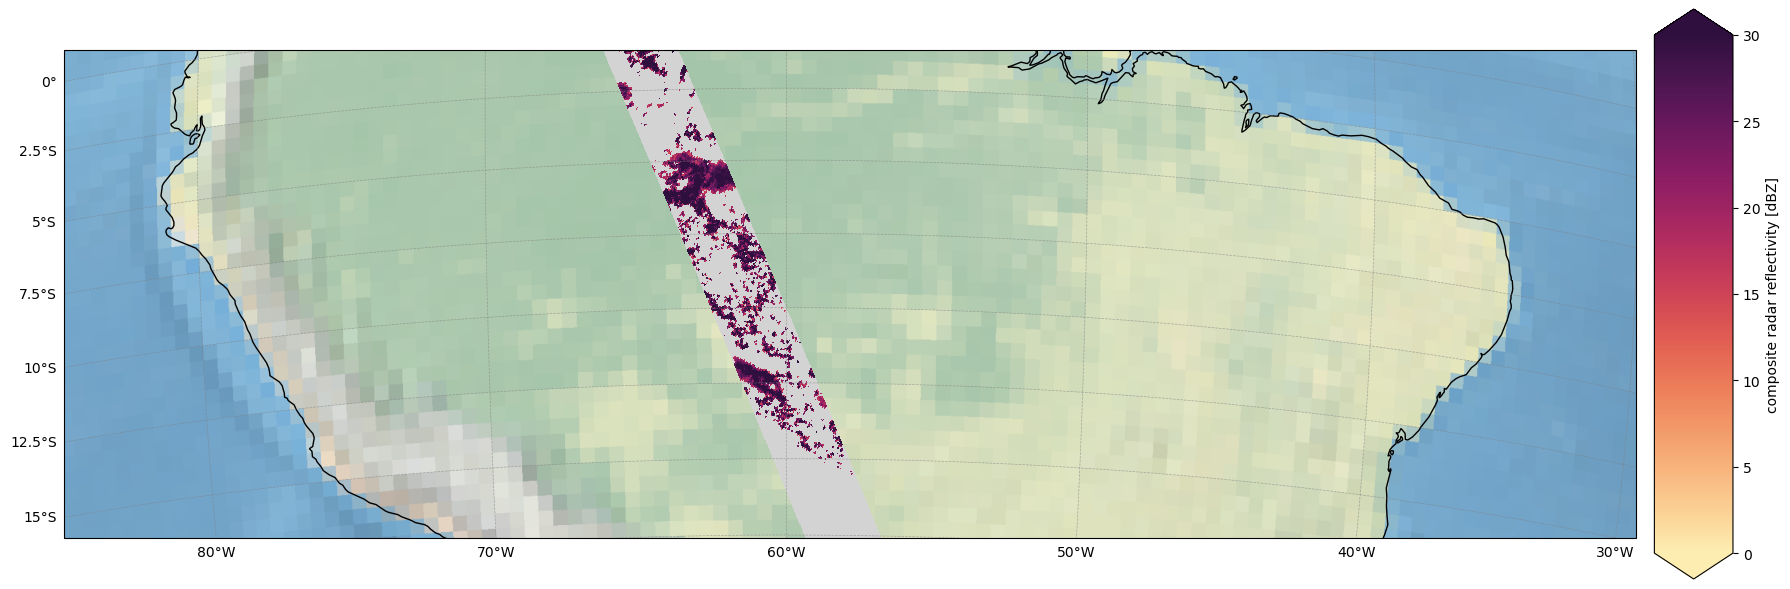

In [10]:
gs = GridSpec(1, 2, width_ratios=[1.0, 0.05])

fig = plt.figure(figsize=(18, 6))
cmap = cmocean.cm.matter
cmap.set_bad("lightgrey")
proj = ccrs.NearsidePerspective(
    central_latitude=-20,
    central_longitude=-60,
)

ax = plt.subplot(gs[0], projection=proj)

# Zoom to South America
ax.set_extent(
    [-85, -30, -15, 0],   # [west, east, south, north]
    crs=ccrs.PlateCarree()
)

ax.stock_img()
ax.coastlines(resolution='50m')

sm = ax.pcolormesh(lons, lats, granule_ds.reflectivity.max('bins'), cmap=cmap, vmin = 0 , vmax = 30, transform=ccrs.PlateCarree()) 

# Gridlines
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.6,
    linestyle='--'
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# Colorbar
cax = plt.subplot(gs[1])
plt.colorbar(sm, extend = 'both', cax=cax, fraction=0.35, pad=0.2, label="composite radar reflectivity [dBZ]")

plt.tight_layout()
plt.show()

# Visualization of regridded data

In [11]:
# read in regridded zarr file 
path = Path('/glade/derecho/scratch/kukulies/gpm_dpr/202002/')
filename = path / 'GPM_DPR_reflectivity_regridded_2020-02-28.zarr'
ds_regridded = xr.open_zarr(filename, consolidated = False) 

lats, lons = ds_regridded.lat.values, ds_regridded.lon.values

granule= 11 # pick the granule that corresponds to the source file above , e.g. 11 
rrefl = ds_regridded.reflectivity[granule].compute()
comp_refl = ds_regridded.column_max_reflectivity[granule].compute()
print('Granule ' + str(granule) +', start:', rrefl.scan_time_start.compute().data, 'end: ',  rrefl.scan_time_end.compute().data)

Granule 11, start: 2020-02-28T15:39:09.364000000 end:  2020-02-28T17:11:43.856000000


The regridded data has the following dimensions: **(time: 16 , lat: 3298, lon: 9896, height: 176)**

The timesteps are for each of the 15-16 granules in the specific day. 

In [12]:
print(ds_regridded.time.values)

['2020-02-28T00:00:00.000000000' '2020-02-28T01:00:00.000000000'
 '2020-02-28T03:00:00.000000000' '2020-02-28T04:00:00.000000000'
 '2020-02-28T06:00:00.000000000' '2020-02-28T07:00:00.000000000'
 '2020-02-28T09:00:00.000000000' '2020-02-28T10:00:00.000000000'
 '2020-02-28T12:00:00.000000000' '2020-02-28T13:00:00.000000000'
 '2020-02-28T15:00:00.000000000' '2020-02-28T16:00:00.000000000'
 '2020-02-28T18:00:00.000000000' '2020-02-28T20:00:00.000000000'
 '2020-02-28T21:00:00.000000000' '2020-02-28T22:00:00.000000000']


In [13]:
ds_regridded

<xarray.Dataset> Size: 379GB
Dimensions:                  (time: 16, lat: 3298, lon: 9896, height: 176)
Coordinates:
  * height                   (height) float32 704B 2.154e+04 ... 0.05814
  * lat                      (lat) float32 13kB -59.98 -59.95 ... 59.95 59.98
  * lon                      (lon) float32 40kB -180.0 -179.9 ... 179.9 180.0
    scan_time_end            (time) datetime64[ns] 128B dask.array<chunksize=(16,), meta=np.ndarray>
    scan_time_start          (time) datetime64[ns] 128B dask.array<chunksize=(16,), meta=np.ndarray>
  * time                     (time) datetime64[ns] 128B 2020-02-28 ... 2020-0...
Data variables:
    column_max_reflectivity  (time, lat, lon) float32 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    freezing_level           (time, lat, lon) float32 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    reflectivity             (time, lat, lon, height) float32 368GB dask.array<chunksize=(1, 512, 512, 176), meta=np.ndarray>
    surface_precip           (time, lat, lon) float32 2GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    swath_edge               (time, lat, lon) int64 4GB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
    swath_mask               (time, lat, lon) int8 522MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>

### Satellite swath edge for a specific overpass - zoom in for better visualization

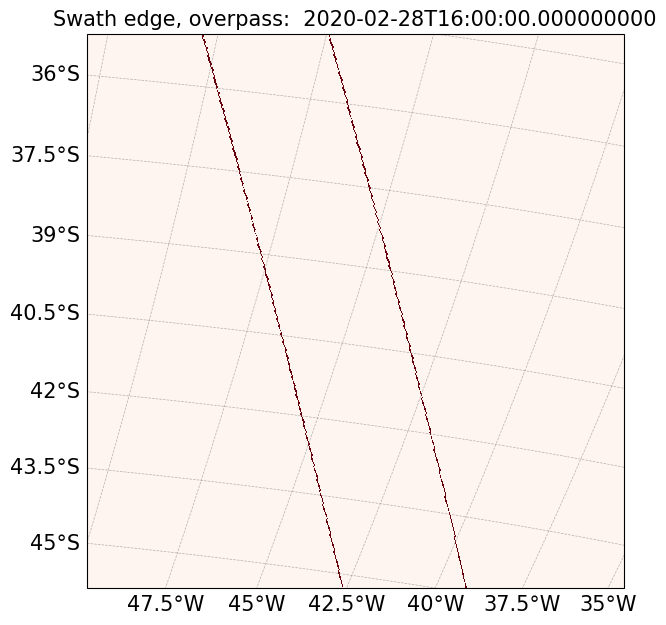

In [20]:
gs = GridSpec(1, 2, width_ratios=[1.0, 0.05])

fig = plt.figure(figsize=(8, 8))
cmap = get_cmap("magma_r")
cmap.set_bad((0, 0, 0, 0)) 
cmap.set_under("lightgrey")
fs = 15
proj = ccrs.NearsidePerspective(central_latitude = -20,
                                central_longitude = -70)

ax = plt.subplot(gs[0], projection=proj)
ax.stock_img()
ax.coastlines()
sm = ax.pcolormesh(lons, lats, ds_regridded.swath_edge[granule].compute(),  cmap='Reds',transform=ccrs.PlateCarree()) 
# zoom in (for better visualization of the swath) 
ax.set_extent([-50,-40, -45, -35])

### add lats and lons for better orientation
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.6,
    linestyle='--')

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': fs}
gl.ylabel_style = {'size': fs}
plt.title('Swath edge, overpass:  ' + str(ds_regridded.time[granule].data), fontsize = fs )
plt.show()

### Plot the entire swath, where 1 is within the swath and 0 is outside: 

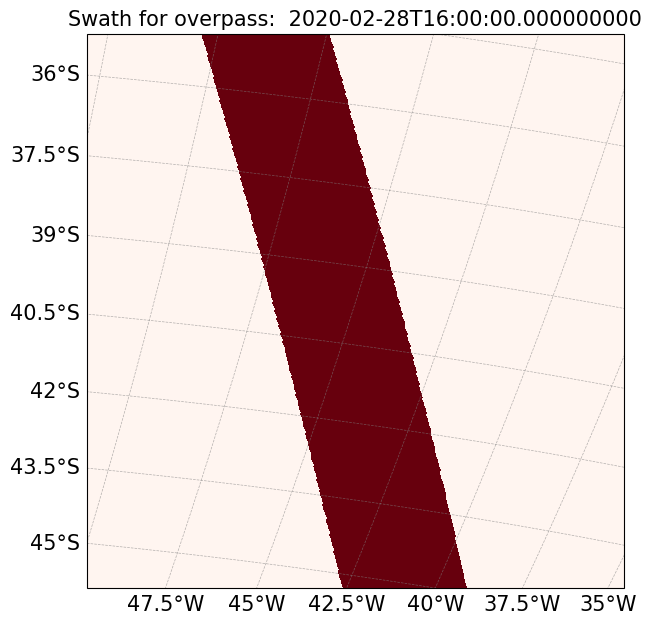

In [21]:
gs = GridSpec(1, 2, width_ratios=[1.0, 0.05])

fig = plt.figure(figsize=(8, 8))
cmap = get_cmap("magma_r")
cmap.set_bad((0, 0, 0, 0)) 
cmap.set_under("lightgrey")
fs = 15
proj = ccrs.NearsidePerspective(central_latitude = -20,
                                central_longitude = -70)

ax = plt.subplot(gs[0], projection=proj)
ax.stock_img()
ax.coastlines()
sm = ax.pcolormesh(lons, lats, ds_regridded.swath_mask[granule].compute(),  cmap='Reds',transform=ccrs.PlateCarree()) 
# zoom in (for better visualization of the swath) 
ax.set_extent([-50,-40, -45, -35])

### add lats and lons for better orientation
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.6,
    linestyle='--')

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': fs}
gl.ylabel_style = {'size': fs}
plt.title('Swath for overpass:  ' + str(ds_regridded.time[granule].data), fontsize = fs )
plt.show()

### Composite reflectivity

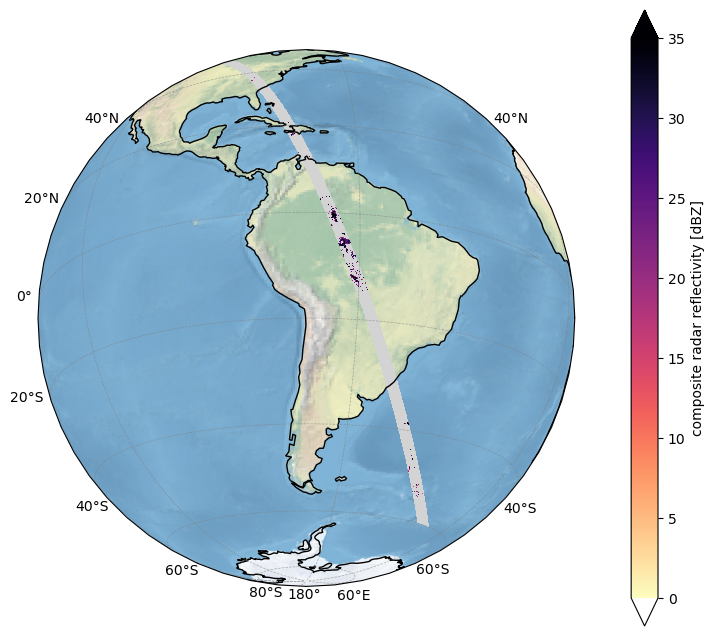

In [23]:
gs = GridSpec(1, 2, width_ratios=[1.0, 0.05])
fig = plt.figure(figsize=(8, 8))
cmap = get_cmap("magma_r")
cmap.set_under((0, 0, 0, 0)) # Transparent: this is for missing values OUTSIDE of the swath (-9999) 
cmap.set_bad("lightgrey") # Lightgray: this is for missing values WITHIN the swath (np.nan)

proj = ccrs.NearsidePerspective(central_latitude = -20,
                                central_longitude = -70)

ax = plt.subplot(gs[0], projection=proj)
ax.stock_img()
ax.coastlines()
sm = ax.pcolormesh(lons, lats, comp_refl,  cmap=cmap, vmin = 0, vmax = 35, transform=ccrs.PlateCarree()) 

### add lats and lons for better orientation
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.6,
    linestyle='--')

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

ax = plt.subplot(gs[1])
plt.colorbar(sm, extend = 'both', cax=ax, fraction=0.35, pad=0.2, label="composite radar reflectivity [dBZ]")
plt.show()

#### Zoom in over South America 

In [24]:
np.unique(comp_refl)

array([-9999.      ,    13.1304  ,    13.339587, ...,    52.023193,
          52.85874 ,          nan], dtype=float32)

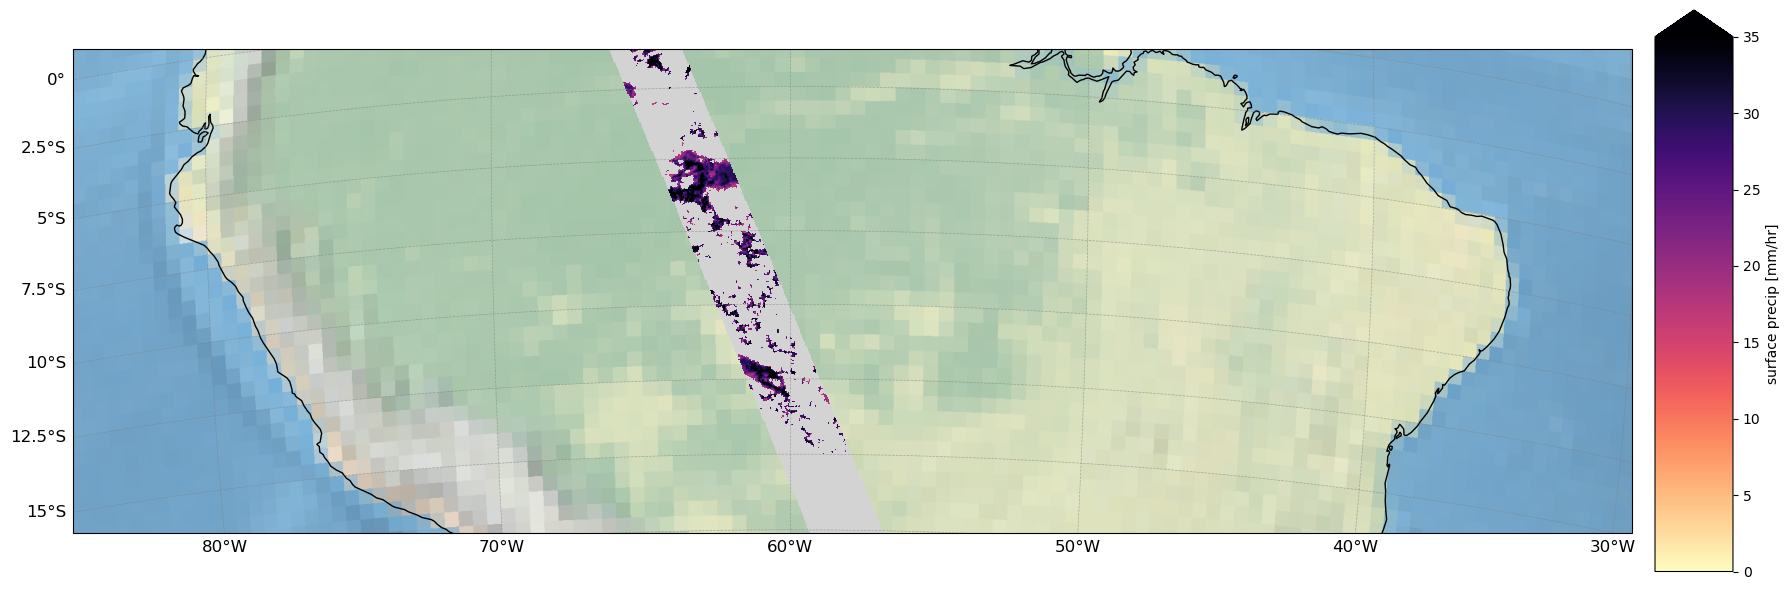

In [26]:
gs = GridSpec(1, 2, width_ratios=[1.0, 0.05])

fig = plt.figure(figsize=(18, 6))

proj = ccrs.NearsidePerspective(
    central_latitude=-20,
    central_longitude=-60,
)

ax = plt.subplot(gs[0], projection=proj)
cmap = get_cmap("magma_r")
cmap.set_under((0, 0, 0, 0)) 
cmap.set_bad("lightgrey") 

# Zoom to South America
ax.set_extent(
    [-85, -30, -15, 0],   # [west, east, south, north]
    crs=ccrs.PlateCarree()
)

ax.stock_img()
ax.coastlines(resolution='50m')
lats, lons = ds_regridded.lat.values, ds_regridded.lon.values
sm = ax.pcolormesh(lons, lats, comp_refl,  cmap=cmap, vmin = 0, vmax = 35, transform=ccrs.PlateCarree()) 

# Gridlines
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.6,
    linestyle='--'
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}

# Colorbar
cax = plt.subplot(gs[1])

plt.colorbar(
    sm,
    extend='max',
    cax=cax,
    fraction=0.35,
    pad=0.2,
    label="surface precip [mm/hr]")

plt.tight_layout()
plt.show()

### Vertical cross section of the regridded 3D reflectivity 

In [27]:
# get heights
heights = ds_regridded.height.compute()
# compute longitudinal maximum reflectivity 
vertical_cross_section = rrefl.max(dim = 'lon')

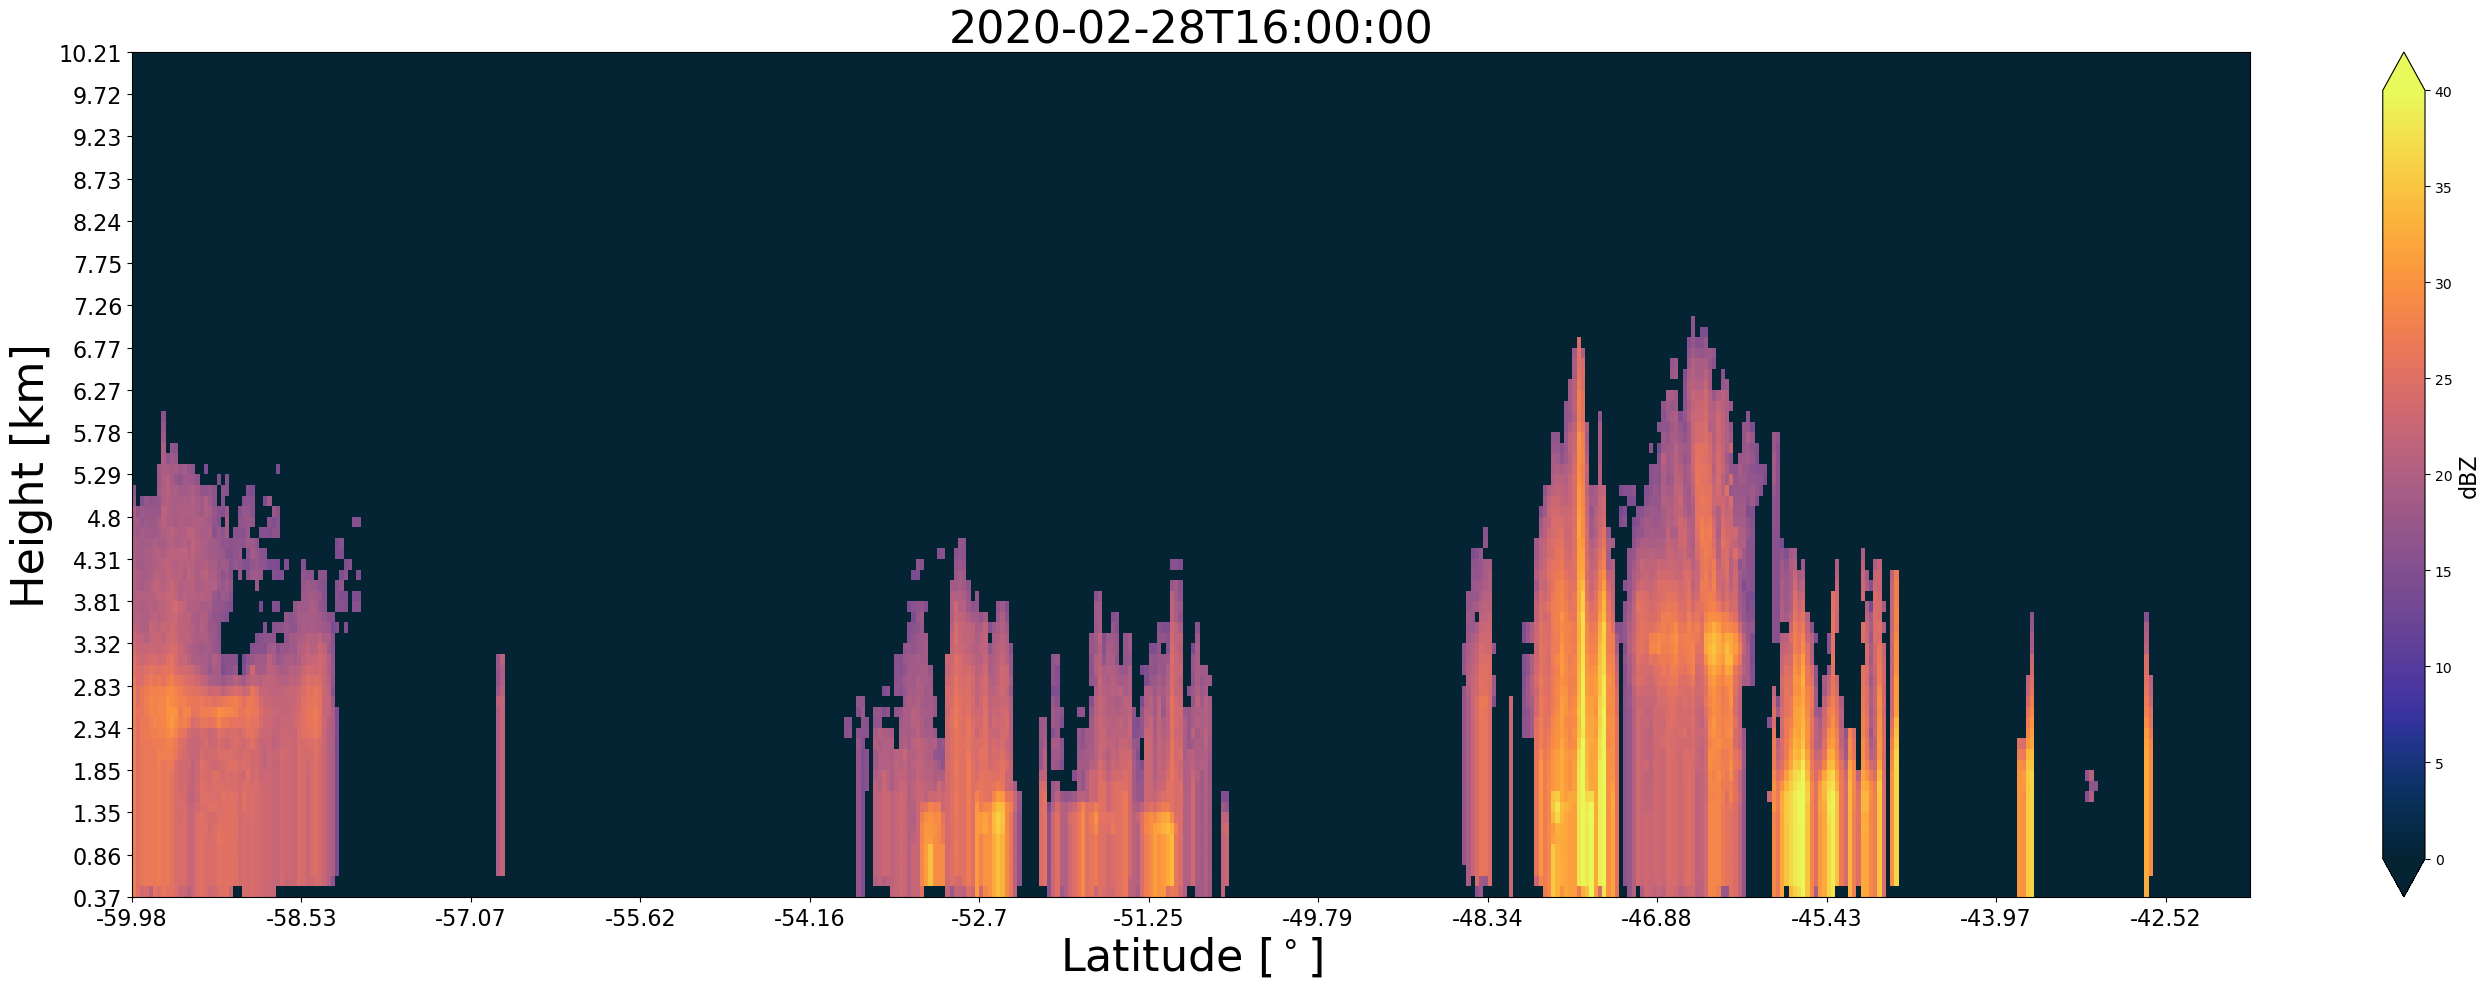

In [28]:
plt.figure(figsize=(28, 10))
fs = 16
plt.pcolormesh(np.flip(vertical_cross_section.T , axis = 0), vmin = 0, vmax = 40, cmap = cmocean.cm.thermal)

plt.xticks(np.arange(rrefl.lat.values.size)[::40], labels = np.round(rrefl.lat.values[::40], decimals = 2), fontsize = fs )
plt.yticks(np.arange(rrefl.height.values.size)[::4], labels = np.flip(np.round(heights.values[::4]/ 1000, decimals = 2 ), axis = 0) , fontsize = fs )
plt.title(str(rrefl.time.values)[0:-10], fontsize = fs* 2)
plt.ylabel('Height [km]', fontsize = fs*2 )
plt.xlabel('Latitude [$^\circ$]', fontsize = fs*2)

plt.ylim(0, 80)
plt.xlim(0, 500)
plt.tight_layout()
plt.colorbar(extend = 'both').set_label(label = 'dBZ', fontsize = fs )
plt.show()